# Taller: ControlNet — Condiciones visuales para Stable Diffusion

## 1.1) Instalación de dependencias

In [1]:
!pip install diffusers transformers accelerate safetensors controlnet_aux

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 11.3 MB/s eta 0:00:00


## 1.2) Cargar modelo base de Stable Diffusion + ControlNet

In [3]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from controlnet_aux import CannyDetector

controlnet_canny = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny",
                                                   torch_dtype=torch.float16)
controlnet_depth = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth",
                                                   torch_dtype=torch.float16)
controlnet_openpose = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-openpose",
                                                      torch_dtype=torch.float16)

pipe_canny = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet_canny,
    torch_dtype=torch.float16,
    safety_checker=None
    ).to("cuda")

pipe_depth = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet_depth,
    torch_dtype=torch.float16,
    safety_checker=None
    ).to("cuda")

pipe_openpose = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet_openpose,
    torch_dtype=torch.float16,
    safety_checker=None
    ).to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results

## 2.1) Preparar imagen de condición (Canny)

In [24]:
from PIL import Image
import numpy as np

image = Image.open("kung_fu2.jpg")
detector = CannyDetector()
condition_image = detector(image)

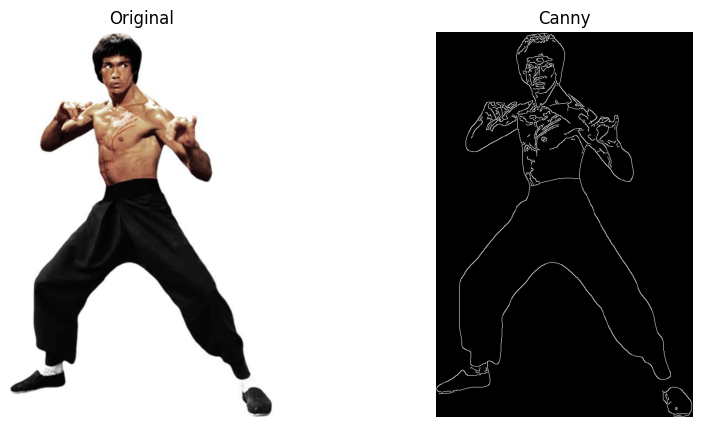

In [25]:
import matplotlib.pyplot as plt
from controlnet_aux import CannyDetector

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(condition_image, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.show()

In [26]:
condition_image.save("canny_result.png")

## 2.2) Preparar imagen de condición (Depth)

In [27]:
from transformers import pipeline

depth_estimator = pipeline(
    task="depth-estimation",
    model="LiheYoung/depth-anything-small-hf"
)

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

In [28]:
result = depth_estimator(image)

depth_image = result["depth"]

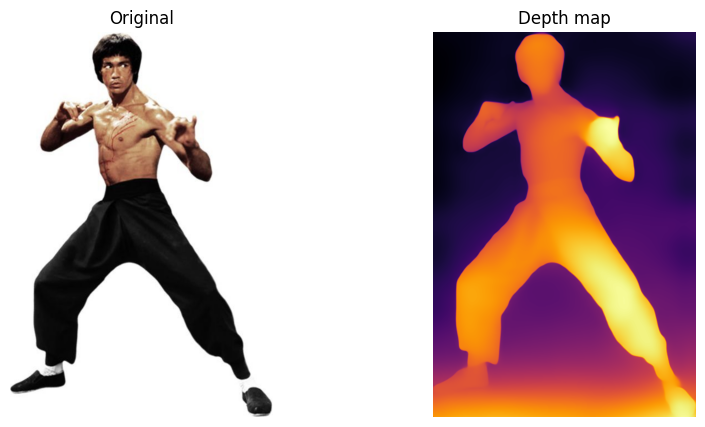

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(depth_image, cmap="inferno")
plt.title("Depth map")
plt.axis("off")

plt.show()

In [30]:
depth_image.save("depth_result.png")

## 2.3) Preparar imagen de condición (OpenPose)

In [31]:
from controlnet_aux import OpenposeDetector
import matplotlib.pyplot as plt

openpose = OpenposeDetector.from_pretrained("lllyasviel/Annotators")


pose_image = openpose(image, include_body=True, include_hand=False, include_face=False)

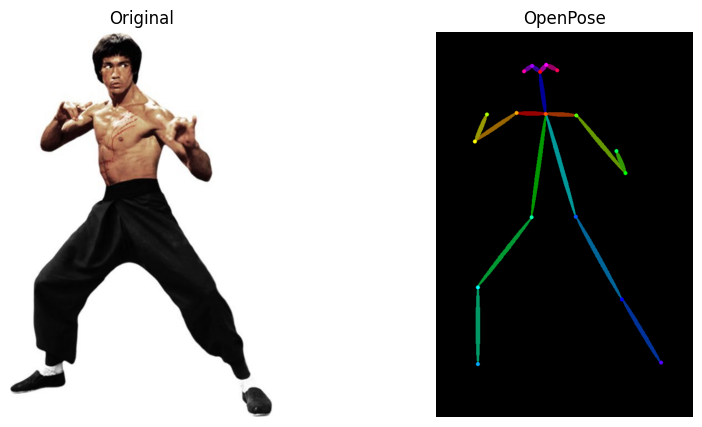

In [32]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pose_image)
plt.title("OpenPose")
plt.axis("off")

plt.show()

In [33]:
pose_image.save("openpose_result.png")

## 3) Generacion de imagenes condicionadas y sin condicionar con prompt

### Solo prompt

In [34]:
from diffusers import StableDiffusionPipeline
import torch

pipe_base = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
result = pipe_base(
    prompt="A cyberpunk martial artist performing a kung fu pose, dynamic action, neon lights, cinematic lighting, ultra detailed, 4k",
    num_inference_steps=40,
    guidance_scale=7.5
).images[0]

result.save("sin_controlnet.png")

  0%|          | 0/40 [00:00<?, ?it/s]

### Canny

In [36]:
result = pipe_canny(
    prompt="A cyberpunk martial artist performing a kung fu pose, dynamic action, neon lights, cinematic lighting, ultra detailed, 4k",
    image=condition_image,
    num_inference_steps=40,
    guidance_scale=7.5,
    controlnet_conditioning_scale=1.3
).images[0]

result.save("canny_controlnet.png")

  0%|          | 0/40 [00:00<?, ?it/s]

### Depth

In [37]:
result = pipe_depth(
    prompt="A cyberpunk martial artist performing a kung fu pose, dynamic action, neon lights, cinematic lighting, ultra detailed, 4k",
    image=depth_image,
    num_inference_steps=40,
    guidance_scale=7.5,
    controlnet_conditioning_scale=1.2
).images[0]

result.save("depth_controlnet.png")

  0%|          | 0/40 [00:00<?, ?it/s]

### OpenPose

In [38]:
result = pipe_openpose(
    prompt="A cyberpunk martial artist performing a kung fu pose, dynamic action, neon lights, cinematic lighting, ultra detailed, 4k",
    image=pose_image,
    num_inference_steps=40,
    guidance_scale=8.0,
    controlnet_conditioning_scale=1.4
).images[0]

result.save("openpose_controlnet.png")

  0%|          | 0/40 [00:00<?, ?it/s]